In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


In [2]:
df=pd.read_csv("Export_ER_Agrege.csv", sep=";")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER',
       'Capital_initial', 'Date_origination', 'Cohorte'],
      dtype='object')

In [3]:
# Filtrer 10 dernieres annees (40 trimestres)
# Cohorte en "période trimestre"
q = pd.PeriodIndex(df["Cohorte"].astype(str), freq="Q")

# 40 trimestres = 10 ans
cutoff = q.max() - 40

# Filtre 10 dernières années (en trimestres)
df_recent = df[q >= cutoff].copy()

print(f"Donnees filtrees (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Periode couverte : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Donnees filtrees (10 ans) : 62449 contrats (98.2%)
Periode couverte : 2013Q4 a 2023Q4
Nombre de cohortes : 41


In [4]:
import numpy as np
import pandas as pd

df = df.copy()
df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")
df = df.dropna(subset=["Date_origination"])

# Cohorte semestrielle (lignes)
# "2Q" = semestre (2 quarters). Exemple: 2021Q1-2021Q2 devient 2021H1.
df["Cohorte_S"] = df["Date_origination"].dt.to_period("2Q").astype(str)

# Age (développement) en mois puis en trimestres (colonnes)
df["age_mois"] = df["NB_ECH"] - df["B_RESMAT"]
df = df[df["age_mois"].notna()]
df = df[df["age_mois"] >= 0]

df["Dev_Q"] = (df["age_mois"] // 3).astype(int)   # 0,1,2,... en trimestres

In [5]:
df["Capital_initial"] = df["MTECH"] * df["B_MAT"]

# Sécurités
df = df[(df["Capital_initial"] > 0) & (df["RA"] >= 0)]

cell = (
    df.groupby(["Cohorte_S", "Dev_Q"], as_index=False)
      .agg(RA_sum=("RA", "sum"),
           Cap_sum=("Capital_initial", "sum"),
           n=("ID", "nunique"))
)

# ER cellulaire (incrémental)
cell["ER_incr"] = cell["RA_sum"] / cell["Cap_sum"]

In [6]:
# Pivot en triangle incrémental
tri_incr = cell.pivot(index="Cohorte_S", columns="Dev_Q", values="ER_incr").sort_index()

# Triangle cumulatif
tri_cum = tri_incr.cumsum(axis=1)
tri_cum.head()

Dev_Q,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
Cohorte_S,,,,,,,,,,,,,,,,,,,,,
2006Q1,NaN,NaN,NaN,NaN,0.024955,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007Q1,NaN,NaN,NaN,NaN,NaN,0.087059,NaN,0.100862,0.100862,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007Q2,NaN,NaN,0.0,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111726,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
MIN_N_CELL = 30
cell_ok = cell[cell["n"] >= MIN_N_CELL].copy()
tri_incr = cell_ok.pivot(index="Cohorte_S", columns="Dev_Q", values="ER_incr").sort_index()
tri_cum = tri_incr.cumsum(axis=1)

In [8]:
import numpy as np

def chain_ladder_factors(tri_cum: pd.DataFrame):
    f = {}
    cols = tri_cum.columns
    for j in range(len(cols)-1):
        c0, c1 = cols[j], cols[j+1]
        num = tri_cum[c1].sum(skipna=True)
        den = tri_cum[c0].sum(skipna=True)
        f[(c0, c1)] = num / den if den > 0 else np.nan
    return pd.Series(f)

factors = chain_ladder_factors(tri_cum)
factors

0   1     2.159300
1   2     1.453589
2   3     1.306189
3   4     1.197463
4   5     1.145705
5   6     1.114688
6   7     1.020573
7   8     1.133476
8   9     1.049394
9   10    0.967099
10  11    1.098893
11  12    0.947586
12  13    1.001674
13  14    0.996040
14  15    0.989337
15  16    0.983778
16  17    0.973136
17  18    0.948413
18  19    0.579231
19  20    0.438901
20  21    0.298411
dtype: float64

In [9]:
tri_proj = tri_cum.copy()

cols = list(tri_proj.columns)
for j in range(len(cols)-1):
    c0, c1 = cols[j], cols[j+1]
    fj = factors[(c0, c1)]
    # là où c1 est manquant mais c0 existe : projeter
    mask = tri_proj[c1].isna() & tri_proj[c0].notna()
    tri_proj.loc[mask, c1] = tri_proj.loc[mask, c0] * fj

tri_proj.tail()

Dev_Q,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
Cohorte_S,,,,,,,,,,,,,,,,,,,,,
2022Q3,0.647814,1.318785,1.934308,2.552437,3.143435,3.569903,3.979327,4.061194,4.603267,4.830639,...,4.864622,4.872766,4.853469,4.801714,4.723822,4.596920,4.359779,2.525317,1.108363,0.330748
2022Q4,0.675311,1.291477,1.908344,2.518953,3.092675,3.543294,3.949667,4.030923,4.568956,4.794634,...,4.828364,4.836447,4.817294,4.765925,4.688613,4.562657,4.327283,2.506495,1.100102,0.328283
2023Q1,0.499139,1.133648,1.766626,2.434967,2.915783,3.340629,3.723758,3.800367,4.307626,4.520396,...,4.552196,4.559817,4.541759,4.493328,4.420439,4.301687,4.079776,2.363131,1.037180,0.309506
2023Q2,0.521931,1.125791,1.743170,2.276910,2.726517,3.123785,3.482045,3.553681,4.028013,4.226972,...,4.256708,4.263834,4.246949,4.201662,4.133503,4.022460,3.814953,2.209738,0.969855,0.289416
2023Q3,0.649982,1.322654,1.922595,2.511274,3.007158,3.445317,3.840453,3.919463,4.442618,4.662056,...,4.694853,4.702712,4.684089,4.634140,4.558966,4.436493,4.207628,2.437187,1.069683,0.319205


In [10]:
import numpy as np
import pandas as pd

df = df.copy()

# --- 1) Formules du prof ---
df["CRD"] = df["MTECH"] * df["B_RESMAT"] - df["RA"]
df["ER"]  = df["RA"] / df["CRD"]

# Capital initial fixe (référence d'agrégation)
df["Capital_initial"] = df["MTECH"] * df["B_MAT"]

# Nettoyage minimum (évite divisions foireuses)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Date_origination", "ER", "Capital_initial", "CRD"])
df = df[(df["Capital_initial"] > 0) & (df["CRD"] > 0)]

# --- 2) Origine en semestre (lignes) ---
df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")
df = df.dropna(subset=["Date_origination"])
df["Cohorte_S"] = df["Date_origination"].dt.to_period("2Q").astype(str)  # semestre

# --- 3) Développement en trimestre (colonnes) ---
# On garde ta logique "reste à maturité" -> âge = NB_ECH - B_RESMAT
df["age_mois"] = df["NB_ECH"] - df["B_RESMAT"]
df = df[df["age_mois"].notna() & (df["age_mois"] >= 0)]
df["Dev_Q"] = (df["age_mois"] // 3).astype(int)

# --- 4) Agrégation cohorte : ER pondéré par capital initial (référence fixe) ---
# (c’est la manière la plus cohérente avec "capital initial comme référence")
cell = (
    df.groupby(["Cohorte_S", "Dev_Q"], as_index=False)
      .agg(ER_w=("ER", lambda x: np.average(x, weights=df.loc[x.index, "Capital_initial"])),
           Cap_sum=("Capital_initial", "sum"),
           n=("ID", "nunique"))
)

# Option : virer les cellules trop petites (sinon facteurs instables)
MIN_N_CELL = 30
cell = cell[cell["n"] >= MIN_N_CELL]

# --- 5) Triangle incrémental puis cumulatif ---
tri_incr = cell.pivot(index="Cohorte_S", columns="Dev_Q", values="ER_w").sort_index()
tri_cum  = tri_incr.cumsum(axis=1)

tri_cum.head()

Dev_Q,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
Cohorte_S,,,,,,,,,,,,,,,,,,,,,
2014Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6.658454e+00,18.13128,NaN,NaN
2014Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.537477e+00,2.209746e+01,NaN,NaN,NaN
2014Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.247593e+01,2.547478e+01,3.265400e+01,NaN,NaN,NaN
2015Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.664358e+00,1.922231e+01,2.617976e+01,3.394854e+01,NaN,NaN,NaN
2015Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.346166,1.166345e+13,1.166345e+13,1.166345e+13,1.166345e+13,NaN,NaN,NaN


Shape triangle cumul: (38, 22)
Taux de NaN: 0.5131578947368421

Facteurs CL:
Dev_Q
0     1.501229e+00
1     3.526045e+00
2     1.114695e+00
3     1.073540e+00
4     1.661379e+00
5     1.000000e+00
6     1.000000e+00
7     1.000000e+00
8     7.643266e-01
9     1.000000e+00
10    1.000000e+00
11    4.439365e+00
12    9.653077e-01
13    9.877599e-01
14    1.133974e+00
15    1.000000e+00
16    1.000000e+00
17    1.000000e+00
18    1.355955e+00
19    1.000000e+00
20    1.059567e-12
dtype: float64


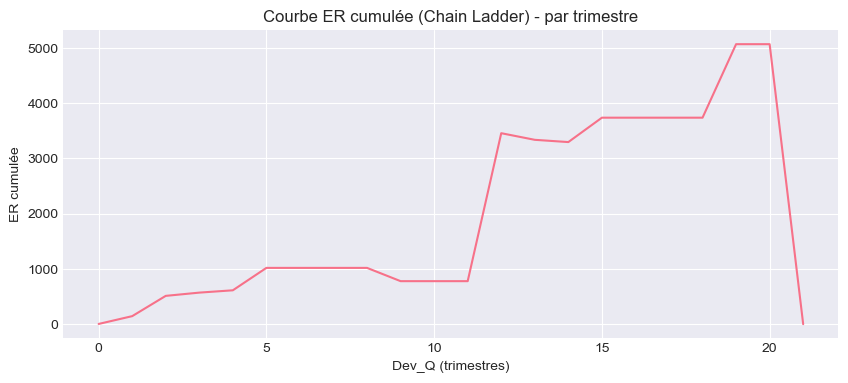

(Dev_Q
 0      4.141071
 1    145.333925
 2    512.453902
 3    571.230041
 4    613.238390
 dtype: float64,
 Dev_Q
 17    3.737817e+03
 18    3.737817e+03
 19    5.068311e+03
 20    5.068311e+03
 21    5.370216e-09
 dtype: float64)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Check rapide du triangle
print("Shape triangle cumul:", tri_cum.shape)
print("Taux de NaN:", tri_cum.isna().mean().mean())

# 2) Facteurs Chain Ladder (sur cumul)
def cl_factors(tri_cum: pd.DataFrame):
    cols = list(tri_cum.columns)
    f = []
    for j in range(len(cols)-1):
        c0, c1 = cols[j], cols[j+1]
        num = tri_cum[c1].sum(skipna=True)
        den = tri_cum[c0].sum(skipna=True)
        f.append(num/den if den > 0 else np.nan)
    return pd.Series(f, index=pd.Index(cols[:-1], name="Dev_Q"))

f = cl_factors(tri_cum)
print("\nFacteurs CL:")
print(f)

# 3) Projection : compléter les NaN à droite
tri_proj = tri_cum.copy()
cols = list(tri_proj.columns)

for j in range(len(cols)-1):
    c0, c1 = cols[j], cols[j+1]
    fj = f.loc[c0]
    mask = tri_proj[c1].isna() & tri_proj[c0].notna()
    tri_proj.loc[mask, c1] = tri_proj.loc[mask, c0] * fj

# 4) Courbe finale ER(t) = moyenne (ou pondérée) de la diagonale projetée
# -> On prend, pour chaque Dev_Q, la valeur la plus "récente" dispo (dernière cohorte observée/projetée)
curve = tri_proj.apply(lambda col: col.dropna().iloc[-1] if col.notna().any() else np.nan)

plt.figure(figsize=(10,4))
plt.plot(curve.index, curve.values)
plt.title("Courbe ER cumulée (Chain Ladder) - par trimestre")
plt.xlabel("Dev_Q (trimestres)")
plt.ylabel("ER cumulée")
plt.grid(True)
plt.show()

curve.head(), curve.tail()